In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_run2/sampler_state.pkl')

In [3]:
sampler.lhs_log_densities.shape

(100000,)

In [32]:
lhs_maxld_val = np.max(sampler.lhs_log_densities)
lhs_maxld_val

np.float64(1.9911894345570982)

In [30]:
lhs_maxld = prior_transform(sampler.lhs_points_initial[np.argmax(sampler.lhs_log_densities)].reshape(1,-1))
lhs_maxld

array([[6.038572  , 1.0744925 , 0.8628779 , 8.700965  , 0.36867952]],
      dtype=float32)

In [31]:
log_density(lhs_maxld)

array([1.99118943])

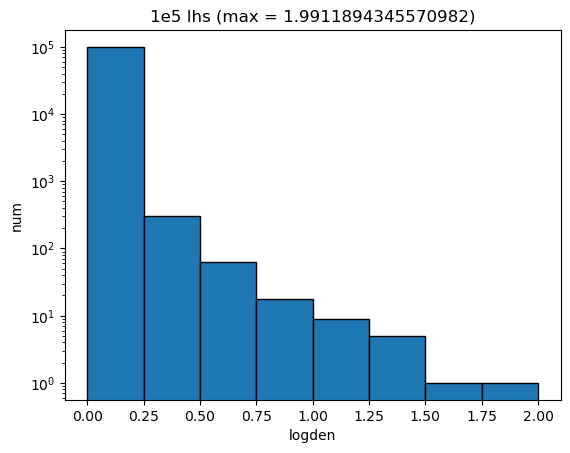

In [33]:
plt.hist(sampler.lhs_log_densities, 
         bins=[0, 0.25, 0.50, 0.75, 1.00, 
               1.25, 1.50, 1.75,2.00],
            #    2.25, 2.50, 2.75,3.00,
            #    3.25,3.5, 3.75,4.00,
            #    4.25,4.5, 4.75,5.00], 
         edgecolor='black')
plt.yscale('log')
plt.title(f'1e5 lhs (max = {lhs_maxld_val})')
plt.xlabel('logden')
plt.ylabel('num')
plt.show()

In [37]:
directory = "/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/study/"
filename = "parisinit_1e5_lhs_1.pkl"
full_path = os.path.join(directory, filename)

with open(full_path, 'wb') as file:
    pickle.dump(sampler.lhs_log_densities, file)

In [36]:
full_path

'/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/study/parisinit_1e5_1.pkl'

In [25]:
np.histogram(sampler.lhs_log_densities, 
         bins=[0, 0.25, 0.50, 0.75, 1.00, 
               1.25, 1.50, 1.75,2.00,
            2.25, 2.50, 2.75,3.00,
               3.25,3.5, 3.75,4.00,
               4.25,4.5, 4.75,5.00])

(array([99596,   306,    64,    18,     9,     5,     1,     1,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 ,
        2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  ]))

In [4]:
sampler.inv_covariances_list[0][-1]

array([[ 4.29603237,  0.04145131,  0.03700106,  0.06065297, -0.02556273],
       [ 0.04145131,  3.85414306, -0.03127478,  0.07025237, -0.08350158],
       [ 0.03700106, -0.03127478,  3.86627789,  0.08901591,  0.0569324 ],
       [ 0.06065297,  0.07025237,  0.08901591,  3.40574152, -0.03980253],
       [-0.02556273, -0.08350158,  0.0569324 , -0.03980253,  3.37163446]])

In [ ]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.342695  ,  0.13357501,  0.271835  ,  0.67808503,  0.92950499],
        [ 0.34271031,  0.13358033,  0.27183138,  0.67808717,  0.92949611],
        [ 0.34269315,  0.13357965,  0.27182742,  0.67808183,  0.92951352],
        ...,
        [ 0.33892944, -0.85339495,  1.231428  , -0.67323755,  0.39684678],
        [ 1.17282589,  1.0939482 ,  0.40520925,  0.94071492,  0.53077525],
        [-0.68538164, -0.23536315,  1.46516017,  0.16654119, -0.72468636]],
       shape=(100000, 5))]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([0.50079079, 0.50063882, 0.50045174, ...,       -inf,       -inf,
              -inf], shape=(100000,))]

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))

# maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))


In [ ]:
maxld_pt1

array([[ 5.87693589,  0.85550847,  0.49798554, 10.12743171,  0.48748133]])

In [ ]:
log_density(maxld_pt1)

array([3.44266976])

In [ ]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [ ]:
gwf.rhostat(h_pt1)

array(4.95250562)

In [ ]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(3.64782346), array(0.00797553))

In [ ]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

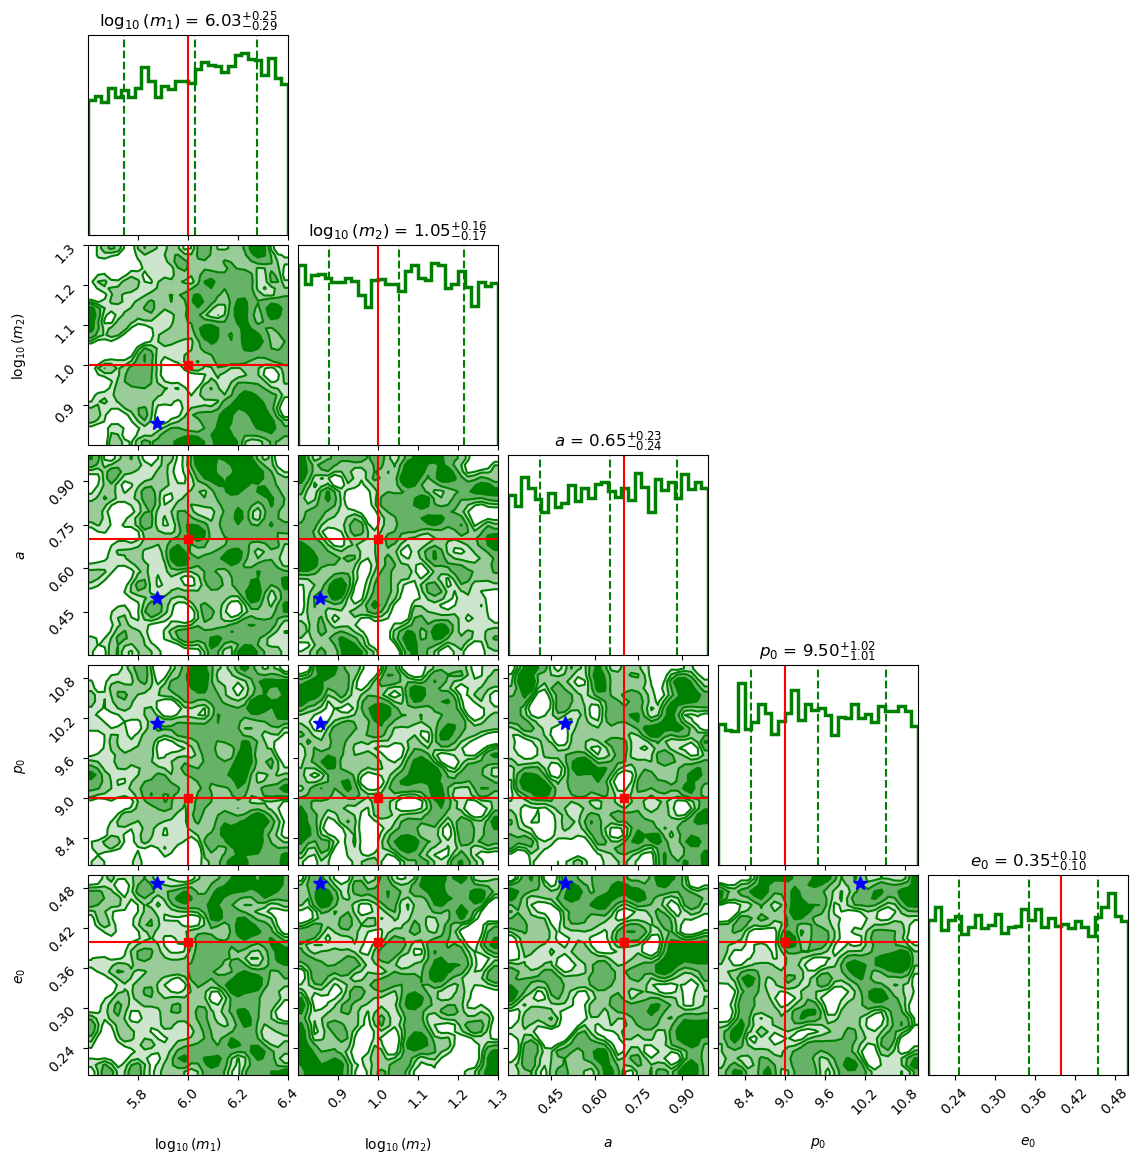

In [ ]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plot

In [ ]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [ ]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[ 5.87693589,  0.85550847,  0.49798554, 10.12743171,  0.48748133]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
# n_points = 50
# t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
# line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]

#NOTE: extended plots till it hits prior boundaries

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
# Per-dimension line points spanning each param's full prior
line_points_per_dim = []
for i in range(5):
    if direction[i] > 0:
        t_lo = (prior_lo[i] - start[i]) / direction[i]
        t_hi = (prior_hi[i] - start[i]) / direction[i]
    elif direction[i] < 0:
        t_lo = (prior_hi[i] - start[i]) / direction[i]
        t_hi = (prior_lo[i] - start[i]) / direction[i]
    else:
        t_lo, t_hi = 0, 1
    t_vals = np.linspace(t_lo, t_hi, n_points)
    line_points_per_dim.append(start[:, np.newaxis] + t_vals * direction[:, np.newaxis])



In [ ]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


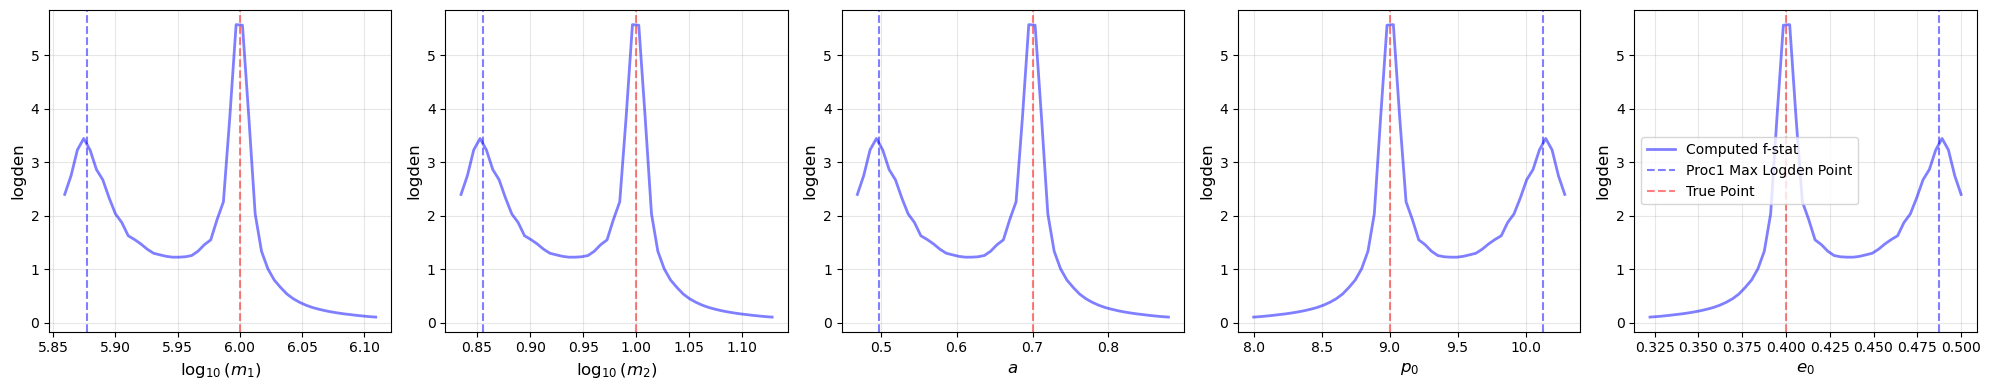

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [ ]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [ ]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat_timemax(data, template)
    X_proc1.append(X.get())

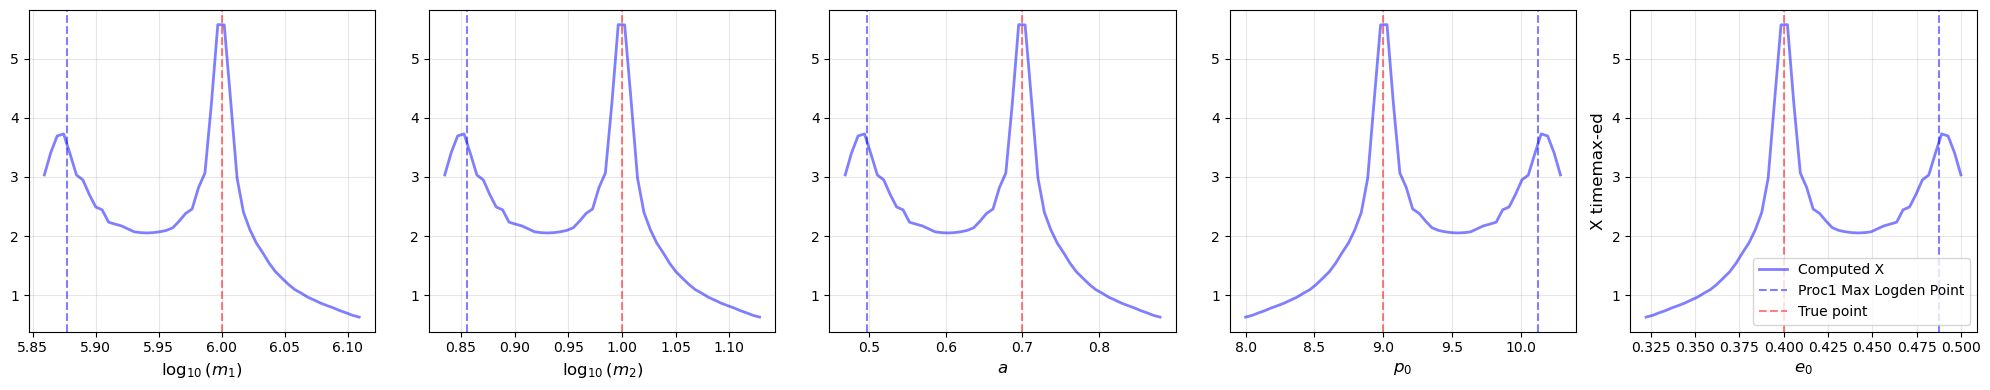

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [ ]:
X_proc1_nont = []
for template in templates_proc1:
    X = gwf.Xstat(data, template)
    X_proc1_nont.append(X.get())

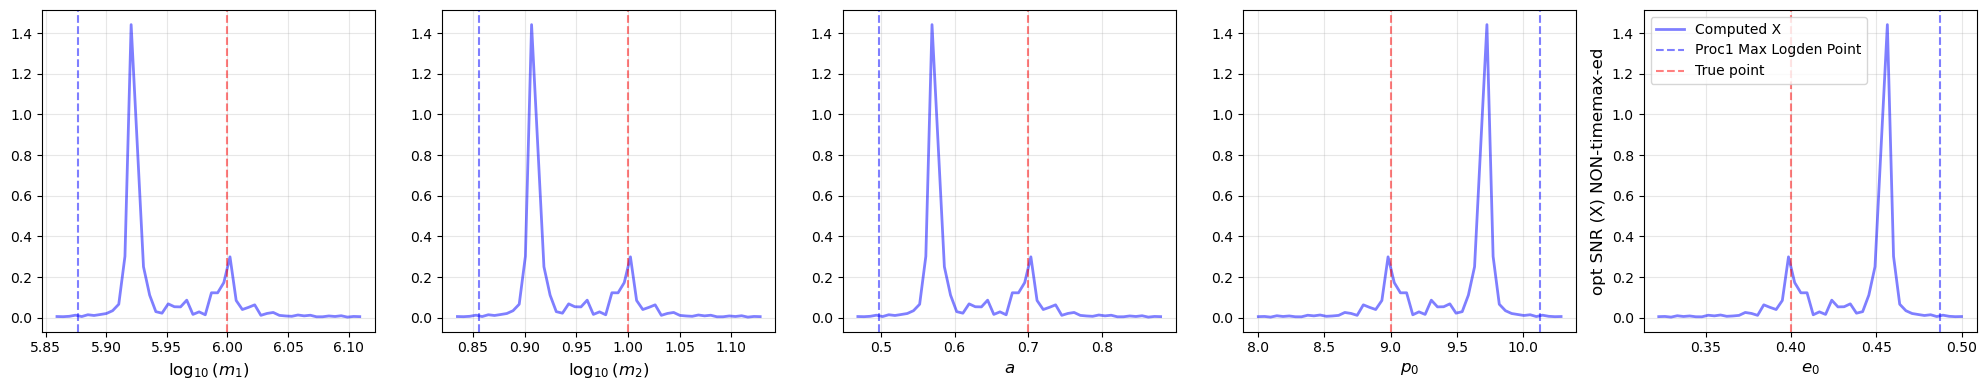

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X) NON-timemax-ed', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [ ]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP (not combined)
    waveforms_per_group = []
    for group in groups:
        mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass group list
                                          include_minus_mkn=False)
        # Sum all modes within this group
        mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form_summed)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [ ]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf.rhostat_modes(hm_arr.T))

In [ ]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf.Xmstat_timemax(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [ ]:
chi2_proc1 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])
    chi2_proc1.append(chi2.get())

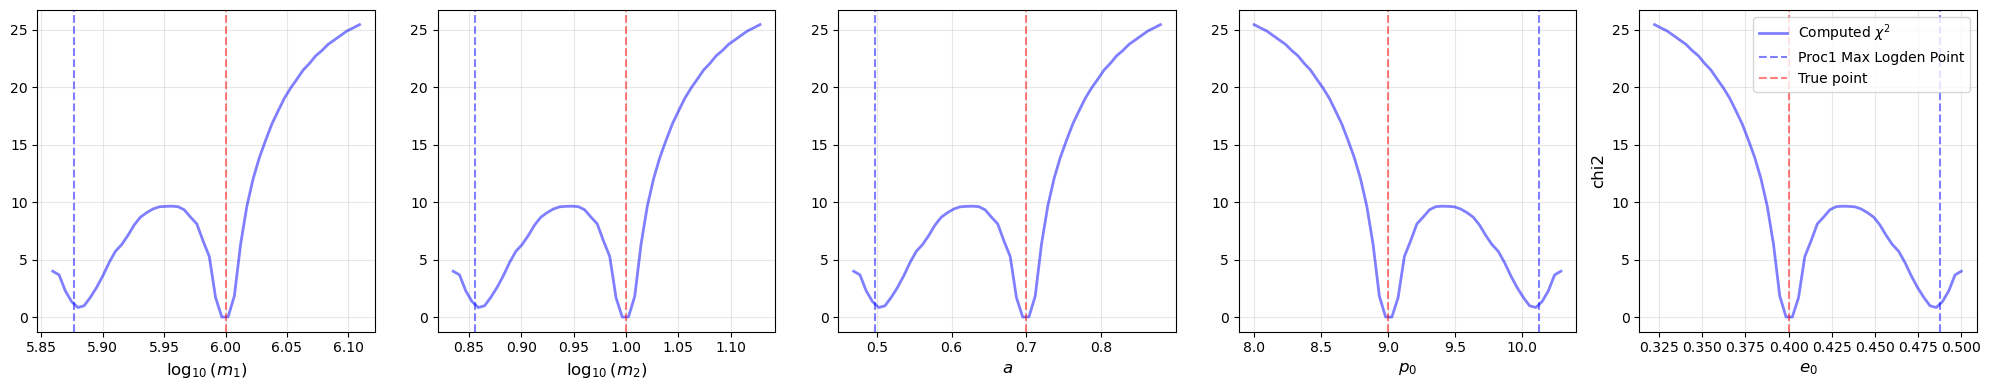

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()


In [ ]:
betas_proc1 = []
for rho_arr in rhostats_proc1:
    rho_tot = np.sqrt(np.sum(rho_arr**2))
    rho_dom_M = np.max(rho_arr)
    beta = gwf.calc_beta(rho_dom_M, rho_tot)
    betas_proc1.append(beta.get())

betas_proc1 = np.array(betas_proc1)

In [ ]:
f_theory = []
for i in range(0, 50):
    f_theor = X_proc1[i] * np.exp(-0.5 * betas_proc1[i] * chi2_proc1[i])
    # print(f_theor)
    f_theory.append(f_theor)

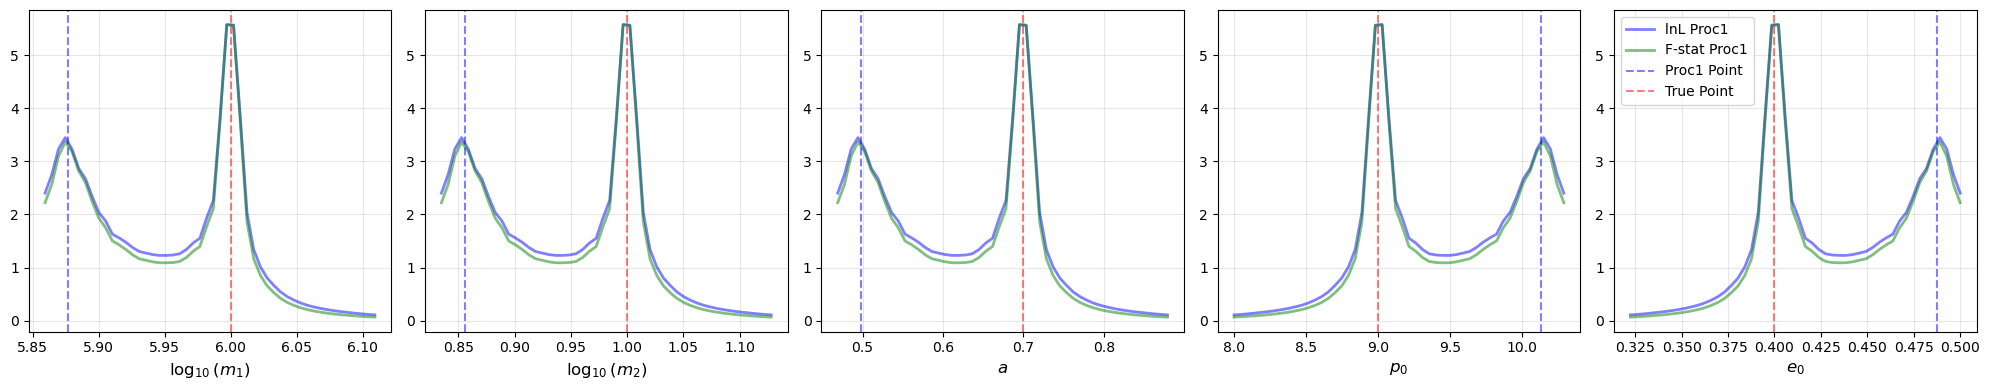

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
for dim in range(5):
    ax = axs_1d[dim]

    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-',
            color='blue', alpha=0.5, linewidth=2, label='lnL Proc1')
    ax.plot(line_points_proc1[dim], f_theory, '-',
            color='green', alpha=0.5, linewidth=2, label='F-stat Proc1')

    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
               alpha=0.5, label='Proc1 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--',
               alpha=0.5, label='True Point')

    ax.set_xlabel(labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()

# extended connection plots

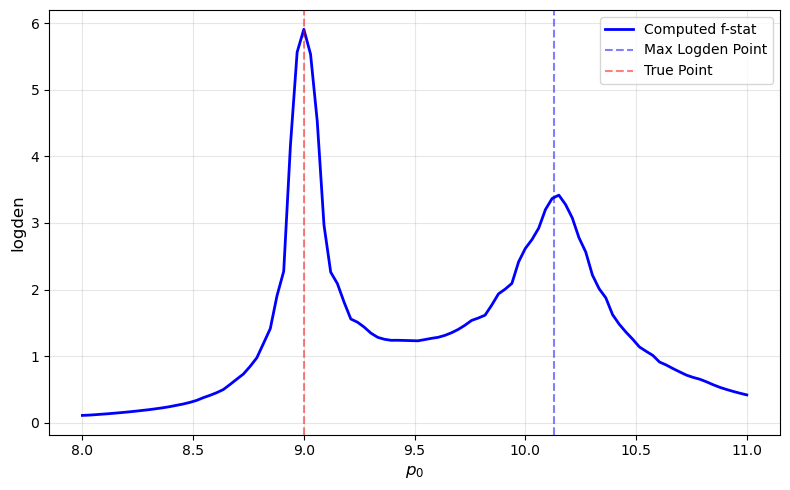

In [ ]:
i = 3  # p0
if direction[i] > 0:
    t_lo_p0 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_p0 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_p0 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_p0 = (prior_lo[i] - start[i]) / direction[i]

n_points = 100
t_values_p0 = np.linspace(t_lo_p0, t_hi_p0, n_points)
line_points_p0 = start[:, np.newaxis] + t_values_p0 * direction[:, np.newaxis]

logden_p0 = log_density(line_points_p0.T)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_p0[3], logden_p0, '-', color='blue', linewidth=2, label='Computed f-stat')
ax.axvline(proc1_maxld_pt_1d[3], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[3],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$p_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [ ]:
def log_density_safe(params):
    params = np.asarray(params)
    n = params.shape[0]
    out = np.full(n, -np.inf)
    for i in range(n):
        try:
            logm1, logm2, a_i, p0_i, e0_i = params[i]
            out[i] = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            out[i] = -np.inf
    return out

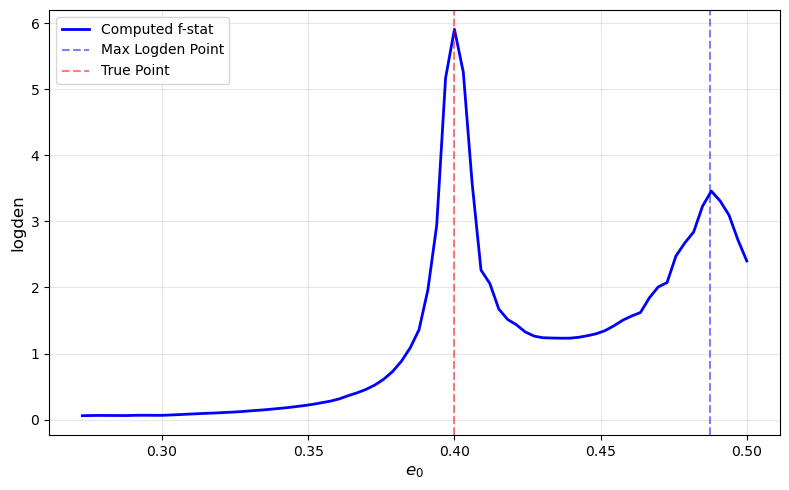

In [ ]:
i = 4  # e0
if direction[i] > 0:
    t_lo_e0 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_e0 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_e0 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_e0 = (prior_lo[i] - start[i]) / direction[i]

n_points = 100
t_values_e0 = np.linspace(t_lo_e0, t_hi_e0, n_points)
line_points_e0 = start[:, np.newaxis] + t_values_e0 * direction[:, np.newaxis]

logden_e0 = log_density_safe(line_points_e0.T)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_e0[4], logden_e0, '-', color='blue', linewidth=2, label='Computed f-stat')
ax.axvline(proc1_maxld_pt_1d[4], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[4],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$e_0$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

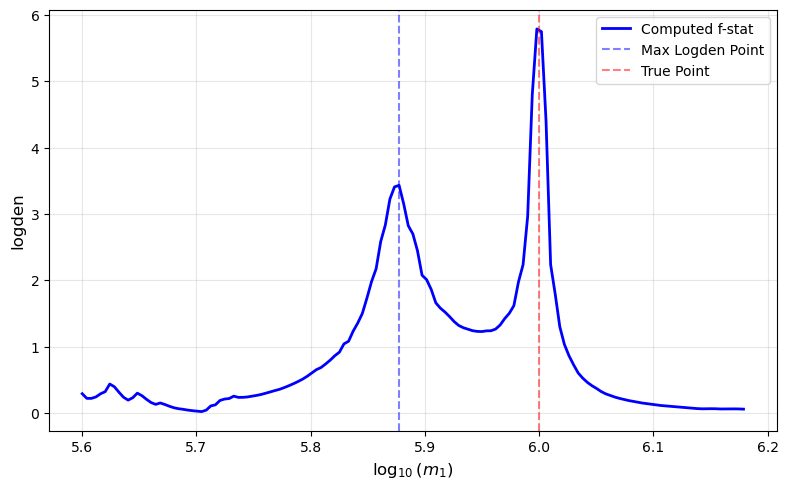

In [ ]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]
n_points = 200

t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)
line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]

logden_logm1 = log_density_safe(line_points_logm1.T)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_logm1, '-', color='blue', linewidth=2, label='Computed f-stat')
ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

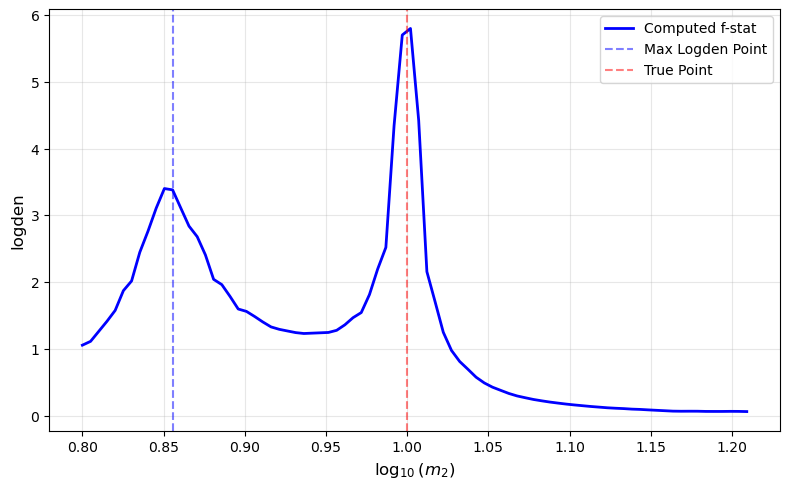

In [ ]:
i = 1  # logm2
if direction[i] > 0:
    t_lo_logm2 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm2 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm2 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm2 = (prior_lo[i] - start[i]) / direction[i]
n_points = 100

t_values_logm2 = np.linspace(t_lo_logm2, t_hi_logm2, n_points)
line_points_logm2 = start[:, np.newaxis] + t_values_logm2 * direction[:, np.newaxis]

logden_logm2 = log_density_safe(line_points_logm2.T)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm2[1], logden_logm2, '-', color='blue', linewidth=2, label='Computed f-stat')
ax.axvline(proc1_maxld_pt_1d[1], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[1],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_2)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

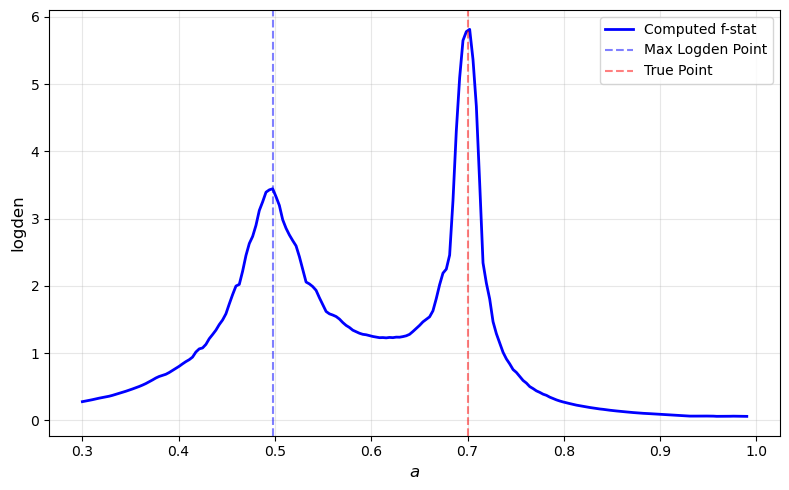

In [ ]:
i = 2  # a
if direction[i] > 0:
    t_lo_a = (prior_lo[i] - start[i]) / direction[i]
    t_hi_a = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_a = (prior_hi[i] - start[i]) / direction[i]
    t_hi_a = (prior_lo[i] - start[i]) / direction[i]
n_points = 200

t_values_a = np.linspace(t_lo_a, t_hi_a, n_points)
line_points_a = start[:, np.newaxis] + t_values_a * direction[:, np.newaxis]

logden_a = log_density_safe(line_points_a.T)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_a[2], logden_a, '-', color='blue', linewidth=2, label='Computed f-stat')
ax.axvline(proc1_maxld_pt_1d[2], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[2],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$a$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()